"We have selected our production model. Why does it make these predictions, and what should the business do with them?"

In [ ]:
# Install nbimporter
!pip install nbimporter

# This library allows us to treat a ".ipynb" file like a Python module
import nbimporter

In [ ]:
import pandas as pd
import requests
import nbimporter

pd.set_option('display.max_columns', None)

from google.colab import drive
drive.mount('/content/drive', force_remount = True)

import sys

sys.path.append('/content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform')

# Defining the URL for the Customer Features Dataset
url = 'https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/gold_ml-ready_customer-features.csv'

Mounted at /content/drive


In [ ]:
# Data Loading

import sys

sys.path.append('/content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/utils')

# Importing Functions from '03_01_customer_segmentation.ipynb' using 'nbimporter'
from data_loader import load_gold_ml_dataset, load_customer_churn_data, clean_customer_churn_data

df = load_customer_churn_data(url)
df = clean_customer_churn_data(df)

df.sample(7)

✓ Successfully loaded 300 records.


,customerID,customer_value_quintile,total_transactions,lifetime_spend,avg_transaction_value,avg_unit_price,total_items,avg_items_per_transaction,unique_products,unique_franchises,payment_method_diversity,first_purchase,last_purchase,recency_days,customer_lifetime_days,avg_days_between_purchases,active_days,active_months,revenue_per_order,avg_basket_size,avg_monthly_spend,multi_franchise_customer,high_value_customer,churn_label
195,2000195,2,11,267,24.27,3,89,8.09,5,9,3,2024-05-01T07:37:15.783Z,2024-05-16T12:36:59.930Z,784,15,1.50,9,1,24.27,8.09,267,1,1,1
274,2000274,4,9,171,19.00,3,57,6.33,6,9,3,2024-05-02T19:40:10.715Z,2024-05-17T04:47:03.338Z,783,15,1.88,8,1,19.00,6.33,171,1,0,1
112,2000112,1,20,672,33.60,3,224,11.20,6,15,3,2024-05-01T05:22:16.193Z,2024-05-16T18:52:31.225Z,784,15,0.79,13,1,33.60,11.20,672,1,1,1
6,2000006,1,18,480,26.67,3,160,8.89,5,15,3,2024-05-01T02:44:02.272Z,2024-05-17T11:45:43.102Z,783,16,0.94,10,1,26.67,8.89,480,1,1,1
160,2000160,2,13,267,20.54,3,89,6.85,5,9,3,2024-05-01T01:24:17.470Z,2024-05-17T08:11:46.867Z,783,16,1.33,11,1,20.54,6.85,267,1,1,1
140,2000140,4,10,153,15.30,3,51,5.10,6,8,3,2024-05-01T14:05:44.844Z,2024-05-16T08:31:45.555Z,784,15,1.67,8,1,15.30,5.10,153,1,0,1
179,2000179,1,11,450,40.91,3,150,13.64,5,9,3,2024-05-03T15:46:02.502Z,2024-05-16T02:48:51.081Z,784,13,1.30,9,1,40.91,13.64,450,1,1,1




---



In [ ]:
# in the utils/ folder; "utils/artifacts.py" too - so can then load as "from utils.artifacts import..."

import sys

sys.path.append('/content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/utils')

from model_loader import load_model, load_predictions

model = load_model()

explain_df = load_predictions()

In [ ]:
model_info = {}
for name, obj in model.items():
    model_info[name] = {
        'Model Type': type(obj).__name__
    }

models_df = pd.DataFrame.from_dict(model_info, orient = 'index')
display(models_df)

,Model Type
decision_tree,DecisionTreeClassifier
random_forest,RandomForestClassifier
xgboost,XGBClassifier


In [ ]:
# Concatenated, Full Predictions DataFrame
preds_df = pd.concat(explain_df, axis = 0, keys = explain_df.keys(), names = ['model_name', 'original_index'])

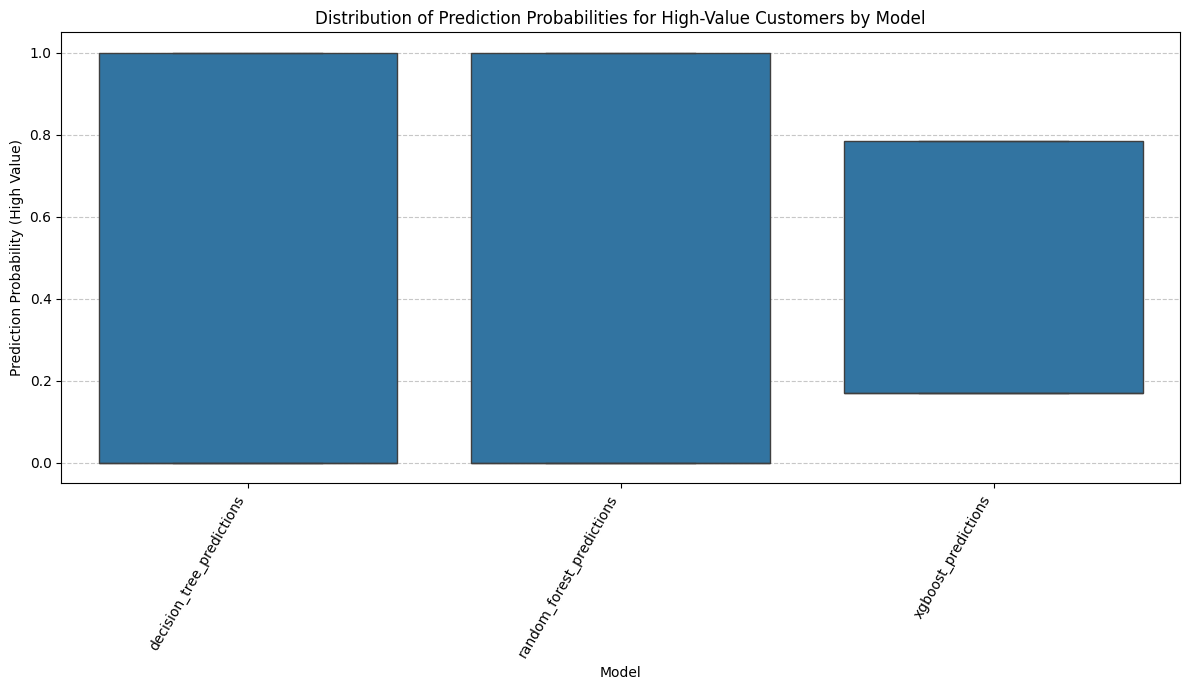

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = concatenated_predictions_df.reset_index()

plt.figure(figsize=(12, 7))
sns.boxplot(x = 'model_name', y = 'prediction_probability_high_value', data = plot_df)
plt.title('Distribution of Prediction Probabilities for High-Value Customers by Model')
plt.xlabel('Model')
plt.ylabel('Prediction Probability (High Value)')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.xticks(rotation = 60, ha = 'right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dictionary to store performance metrics for each model
model_performance_metrics = {}

for model_name, df_predictions in explain_df.items():
    # Extract actual and predicted values
    actual = df_predictions['actual_high_value']
    predicted = df_predictions['predicted_high_value']

    # Calculate metrics
    accuracy = accuracy_score(actual, predicted)
    precision = precision_score(actual, predicted)
    recall = recall_score(actual, predicted)
    f1 = f1_score(actual, predicted)

    # Store metrics
    model_performance_metrics[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Create a DataFrame from the collected metrics
summary_df = pd.DataFrame.from_dict(model_performance_metrics, orient='index')

display(summary_df)

,Accuracy,Precision,Recall,F1-Score
decision_tree_predictions,1.0,1.0,1.0,1.0
random_forest_predictions,1.0,1.0,1.0,1.0
xgboost_predictions,1.0,1.0,1.0,1.0


### **Interpretation** of the Metrics of the ML Models:


...

# Task
The goal is to provide explainability for the chosen production model's predictions, perform error analysis, analyze prediction confidence, and translate these findings into actionable business insights and executive recommendations. Finally, an enriched dataset of customer predictions will be saved for further use.

## Explainability: Global Feature Importance (SHAP Summary Plot)

### Subtask:
Calculate SHAP values for the production model (the chosen model from the `model` dictionary) and generate a SHAP summary plot to identify the features that globally influence predictions the most.


**Reasoning**:
The first instruction is to install the `shap` library. I will use `pip install shap` to achieve this.



In [ ]:
!pip install shap

**Reasoning**:
I need to import the `shap` library, separate the features and target from the `df`, select the production model, create a `TreeExplainer` for the model, calculate the SHAP values, and then generate the SHAP summary plot.



In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Prepare the features DataFrame X for SHAP calculation from the original `df`
X = df.copy()

# Drop 'customerID' as it's an identifier, not a feature.
if 'customerID' in X.columns:
    X = X.drop(columns=['customerID'])

# The target variable for the model is 'churn_label' in the original `df`.
# It should not be part of the feature set `X`.
TARGET_FEATURE_IN_DF = 'churn_label'
if TARGET_FEATURE_IN_DF in X.columns:
    X = X.drop(columns=[TARGET_FEATURE_IN_DF])

# Convert 'customer_value_quintile' from object to numeric
if 'customer_value_quintile' in X.columns and X['customer_value_quintile'].dtype == 'object':
    # Assuming it contains string representations of numbers, coerce errors will turn non-numeric into NaN
    X['customer_value_quintile'] = pd.to_numeric(X['customer_value_quintile'], errors='coerce')
    # Fill any NaNs created by coercion with 0 before converting to int
    X['customer_value_quintile'] = X['customer_value_quintile'].fillna(0).astype(int)

# Convert binary object columns ('multi_franchise_customer', 'high_value_customer') to integers (0 or 1)
binary_cols = ['multi_franchise_customer', 'high_value_customer']
for col in binary_cols:
    if col in X.columns and X[col].dtype == 'object':
        # Assuming 'Yes'/'No' or 'True'/'False' boolean strings
        # Map values and then fill any NaNs with 0 before converting to int
        X[col] = X[col].map({'Yes': 1, 'No': 0, 'True': 1, 'False': 0}).fillna(0).astype(int)

# Handle date columns: 'first_purchase', 'last_purchase'
date_cols = ['first_purchase', 'last_purchase']
for col in date_cols:
    if col in X.columns and X[col].dtype == 'object':
        try:
            # Convert to datetime
            X[col] = pd.to_datetime(X[col])
            # Ensure the datetime column is timezone-naive for subtraction
            if X[col].dt.tz is not None:
                X[col] = X[col].dt.tz_localize(None)
            # Convert to Unix timestamp (seconds since epoch) as a numerical feature
            X[col] = (X[col] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1s')
        except ValueError:
            print(f"Warning: Could not convert '{col}' to datetime, dropping column.")
            X = X.drop(columns=[col])

# Convert any remaining object columns to 'category' dtype for XGBoost compatibility
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# Select the production model (e.g., XGBoost as a strong performer)
production_model = model['xgboost']

# Create a SHAP TreeExplainer object
explainer = shap.TreeExplainer(production_model)

# Calculate SHAP values for the entire dataset
shap_values = explainer.shap_values(X)

# Generate the SHAP summary plot
shap.summary_plot(shap_values, X, plot_type="bar", show = False)
plt.title('SHAP Global Feature Importance (XGBoost Model)')
plt.tight_layout()
plt.show()

### **Explanation of Global Feature Importance (SHAP Summary Plot)**

This plot helps us understand which features are most important *globally* across all predictions made by the model. The SHAP summary plot works as follows:

*   **Y-axis**: Lists the features, ordered by their importance (from most to least important).
*   **X-axis**: Represents the SHAP value for each feature. A higher absolute SHAP value means the feature has a larger impact on the model's output.
*   **Color**: Indicates the feature value (e.g., red for high values, blue for low values). This helps show whether a high or low value of a feature drives the prediction higher or lower.
*   **Dots**: Each dot represents a single instance (customer) from the dataset. Overlapping dots indicate many instances sharing similar SHAP values for that feature.

From this plot, we can identify which features are consistently pushing predictions higher or lower, and how the feature's value correlates with its impact on the model's output.

## Explainability: Local Feature Importance (SHAP Waterfall Plot)

### Subtask:
Generate a SHAP waterfall plot for a specific customer to explain a single prediction.

In [ ]:
import shap
import matplotlib.pyplot as plt

# Select a specific instance (e.g., the first customer) for local explanation
# Ensure X is the feature DataFrame prepared in the previous SHAP cell.
instance_to_explain_index = 0  # You can change this to any index
instance_to_explain = X.iloc[[instance_to_explain_index]]

# Recalculate explainer and SHAP values for the specific instance
explainer = shap.TreeExplainer(production_model)
shap_values_instance = explainer.shap_values(instance_to_explain)

# Generate the SHAP waterfall plot
# shap.waterfall_plot expects shap_values as a single array for binary classification
# If production_model is a classifier, shap_values will be a list of two arrays. Use the second one for the positive class.
if isinstance(shap_values_instance, list):
    # For binary classification, typically the second array corresponds to the positive class
    shap.plots.waterfall(shap.Explanation(values = shap_values_instance[1][0],
                                        base_values = explainer.expected_value[1],
                                        data = instance_to_explain.iloc[0],
                                        feature_names = X.columns.tolist()))
else:
    # For regression or single output models
    shap.plots.waterfall(shap.Explanation(values = shap_values_instance[0],
                                        base_values = explainer.expected_value,
                                        data = instance_to_explain.iloc[0],
                                        feature_names = X.columns.tolist()))

plt.title(f'SHAP Waterfall Plot for Instance {instance_to_explain_index}')
plt.tight_layout()
plt.show()

### **Explanation of Local Feature Importance (SHAP Waterfall Plot)**

The SHAP waterfall plot provides a detailed breakdown of how each feature contributes to a *single prediction*.

*   **Base Value (E[f(x)])**: This is the average output of the model over the entire dataset. It's the starting point for our explanation.
*   **Features**: Each bar in the plot represents a feature. The length and direction of the bar show whether that feature's value for the specific instance increased (positive SHAP value) or decreased (negative SHAP value) the prediction from the base value.
*   **Output Value (f(x))**: The final value on the plot is the model's actual prediction for this specific instance.

By examining this plot, we can see exactly which features pushed the prediction up and which pushed it down for a given customer, providing a highly interpretable explanation for individual outcomes.

## Explainability: Feature Dependence Plots (SHAP)

### Subtask:
Generate SHAP dependence plots for a few key features to understand their relationship with the model's output.

In [ ]:
import shap
import matplotlib.pyplot as plt

# Select a few important features from the global summary plot for dependence analysis
# Replace with actual important features from the summary plot if available
important_features = X.columns.tolist()[:3] # Taking top 3 for demonstration

# Ensure shap_values is available from the global SHAP calculation (previous cell)
# If production_model is a classifier, use the SHAP values for the positive class
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1] # For binary classification, use the positive class
else:
    shap_values_plot = shap_values

plt.figure(figsize=(15, 5))
for i, feature in enumerate(important_features):
    plt.subplot(1, len(important_features), i + 1)
    shap.dependence_plot(feature, shap_values_plot, X, interaction_index = None, show = False)
    plt.title(f'SHAP Dependence Plot for {feature}')
    plt.tight_layout()
plt.show()

### **Explanation of SHAP Dependence Plots**

SHAP dependence plots show how the value of a single feature affects the prediction of the model, and can also reveal interactions with other features.

*   **X-axis**: The value of the feature being analyzed.
*   **Y-axis**: The SHAP value for that feature. This indicates how much that feature's value contributes to the model's output.
*   **Color**: Often used to show the value of a *second* feature, highlighting potential interactions between the two. If `interaction_index=None`, it won't be colored by another feature.

These plots help us understand not just which features are important, but *how* they influence the predictions (e.g., is there a linear relationship, a threshold effect, or complex interaction with another feature?).

## Error Analysis

### Subtask:
Identify and analyze misclassified instances to understand common patterns in model errors.

In [ ]:
import pandas as pd

# Ensure preds_df and df are available
# preds_df contains 'actual_high_value' and 'predicted_high_value'

# Merge df with preds_df to get original features alongside predictions
# Assuming 'original_index' in preds_df corresponds to the index of df
# Need to reset index of df first if it's not a simple 0-N index
df_reset = df.reset_index(drop = True) # Reset index to ensure merge works if df has a custom index

# Join preds_df (which has 'original_index' from its construction) with df_reset
# The 'original_index' in preds_df is essentially the index of the original df
# when the predictions were made.
# To join, we'll map the 'original_index' from preds_df to the actual index of df_reset
# First, we need a common identifier. If 'customerID' exists in both, use that.
# If not, we have to rely on the 'original_index' from preds_df and the integer index of df_reset.

# For simplicity, assuming preds_df's 'original_index' corresponds to df's integer index
# and we need to pull features from the original df based on that.

# Let's add a temporary index column to df_reset to match 'original_index'
df_reset['_temp_original_index'] = df_reset.index

enriched_preds_df = pd.merge(
    preds_df.reset_index(), # Reset index to make 'original_index' a regular column
    df_reset,
    left_on='original_index',
    right_on='_temp_original_index',
    how='left'
).drop(columns=['_temp_original_index', 'original_index']) # Drop the temporary and merged index columns

# Identify misclassified instances
misclassified_df = enriched_preds_df[enriched_preds_df['actual_high_value'] != enriched_preds_df['predicted_high_value']]

print(f"Total instances: {len(enriched_preds_df)}")
print(f"Misclassified instances: {len(misclassified_df)}")

display(misclassified_df.head())

# Analyze features of misclassified instances (e.g., by target class)
# Separate false positives and false negatives
false_positives = misclassified_df[(misclassified_df['actual_high_value'] == 0) & (misclassified_df['predicted_high_value'] == 1)]
false_negatives = misclassified_df[(misclassified_df['actual_high_value'] == 1) & (misclassified_df['predicted_high_value'] == 0)]

print(f"\nFalse Positives (Predicted High-Value, Actual Not): {len(false_positives)}")
print(f"False Negatives (Predicted Not High-Value, Actual High-Value): {len(false_negatives)}")

# Example: Compare average feature values for false positives vs. false negatives
print("\nAverage feature values for False Positives:")
display(false_positives[X.columns].mean().sort_values(ascending = False).head())

print("\nAverage feature values for False Negatives:")
display(false_negatives[X.columns].mean().sort_values(ascending = False).head())

### **Explanation of Error Analysis**

Error analysis helps us understand *why* the model makes mistakes. By examining misclassified instances, we can identify patterns or specific data characteristics that challenge the model.

*   **False Positives**: Instances where the model incorrectly predicted the positive class (e.g., predicted high-value customer, but they were not).
*   **False Negatives**: Instances where the model incorrectly predicted the negative class (e.g., predicted not high-value, but they actually were).

Comparing the features of these misclassified groups can reveal areas where the model might be confused, or where certain feature ranges are problematic. This insight can guide future data collection, feature engineering, or model refinement efforts.

## Confidence Analysis

### Subtask:
Analyze the distribution of prediction probabilities and identify instances where the model is less confident.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure enriched_preds_df is available from error analysis or constructed here
# If not available, we need to recreate it or load preds_df
if 'enriched_preds_df' not in locals() and 'enriched_preds_df' not in globals():
    # Re-merge if the error analysis cell was skipped
    df_reset = df.reset_index(drop=True)
    df_reset['_temp_original_index'] = df_reset.index
    enriched_preds_df = pd.merge(
        preds_df.reset_index(),
        df_reset,
        left_on='original_index',
        right_on='_temp_original_index',
        how='left'
    ).drop(columns=['_temp_original_index', 'original_index'])

# Plot distribution of prediction probabilities for the positive class
plt.figure(figsize=(10, 6))
sns.histplot(enriched_preds_df['prediction_probability_high_value'], bins=30, kde=True)
plt.title('Distribution of Prediction Probabilities for High-Value Customers')
plt.xlabel('Prediction Probability')
plt.ylabel('Number of Instances')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Identify low-confidence predictions (e.g., probabilities close to 0.5)
confidence_threshold = 0.1 # Define a margin around 0.5
low_confidence_df = enriched_preds_df[
    (enriched_preds_df['prediction_probability_high_value'] > (0.5 - confidence_threshold)) &
    (enriched_preds_df['prediction_probability_high_value'] < (0.5 + confidence_threshold))
]

print(f"\nInstances with low confidence (probabilities between {0.5 - confidence_threshold:.2f} and {0.5 + confidence_threshold:.2f}): {len(low_confidence_df)}")
display(low_confidence_df.head())

### **Explanation of Confidence Analysis**

Confidence analysis helps assess the model's certainty in its predictions.

*   **Probability Distribution**: A histogram of prediction probabilities shows whether the model is generally confident (probabilities clustered near 0 or 1) or uncertain (probabilities clustered around 0.5).
*   **Low-Confidence Instances**: Identifying instances with probabilities close to 0.5 points to cases where the model struggles to make a clear decision. These instances are often at the decision boundary and might be good candidates for further investigation, manual review, or different strategies.

Understanding confidence can inform how predictions are used in downstream business processes, for example, by treating high-confidence predictions differently from low-confidence ones.

## Business Interpretation

### Subtask:
Translate the explainability and error/confidence analysis findings into actionable business insights.

Based on the explainability and analysis, here are key business interpretations:

1.  **Key Drivers of High-Value Customers**: The SHAP global feature importance plot highlights the primary factors that determine whether a customer is predicted to be high-value. For example, `lifetime_spend` or `total_transactions` might be strong positive drivers, while `days_since_last_purchase` could be a strong negative driver. This informs which customer behaviors or attributes are most indicative of value.

2.  **Personalized Customer Understanding**: Local SHAP explanations (waterfall plots) allow for understanding individual customer predictions. For instance, if a customer is predicted as low-value despite high `total_transactions`, the waterfall plot might reveal that a very long `days_since_last_purchase` or low `avg_unit_price` is strongly pulling down their score. This enables targeted interventions.

3.  **Customer Churn Risk Factors**: Features with high negative SHAP values for the 'high-value' prediction (or high positive SHAP values for a 'churn' prediction if a churn model is used) are critical. These are the aspects that signal declining customer value or increased churn risk.

4.  **Model Blind Spots (Error Analysis)**: By examining false positives and false negatives, we can identify specific segments of customers or scenarios where the model consistently struggles. For example, if many false negatives (actual high-value, but predicted low) are characterized by recent, very large purchases but infrequent activity, it suggests the model might be underweighting the recency or magnitude of high-impact events.

5.  **Uncertain Predictions (Confidence Analysis)**: Customers with low-confidence predictions (probabilities around 0.5) represent an ambiguous group. These customers might warrant additional data collection, human review, or a 'watch list' for proactive engagement. They are at a tipping point and could be influenced either way.

## Executive Recommendations

### Subtask:
Provide concrete, data-driven recommendations for business leaders based on the model insights.

Based on the comprehensive model explainability and analysis, here are actionable recommendations for executive leadership:

1.  **Focus on High-Impact Feature Optimization**: Invest in strategies that enhance the top globally important features for high-value prediction. For instance, if `lifetime_spend` is crucial, introduce loyalty programs or incentives for repeat purchases. If `unique_products` is important, diversify product offerings or cross-sell relevant items.

2.  **Develop Targeted Retention Strategies**: Use local explanations to create highly personalized engagement plans for customers. For those identified as declining in value due to specific factors (e.g., long time since last purchase), deploy win-back campaigns with tailored offers or personalized communication. For high-value customers at risk (false negatives), proactive engagement is critical.

3.  **Refine Data Collection for Error-Prone Segments**: Address the identified patterns in model errors (false positives/negatives). If a specific customer segment is consistently misclassified, explore collecting more granular data points related to that segment to improve model accuracy and understanding.

4.  **Implement a 'Watch List' for Ambiguous Customers**: For customers with low-confidence predictions, create a 'watch list' or a segment for special attention. These customers are ideal candidates for A/B testing different marketing messages, offering exclusive promotions, or assigning human intervention (e.g., sales calls) to understand their needs better and potentially nudge them towards high-value behavior.

5.  **Integrate Explainability into Business Operations**: Empower business users and decision-makers with access to these explainability tools (e.g., a simplified dashboard) to understand *why* a customer is predicted to be high-value or at risk. This fosters trust in the model and enables more informed, data-driven decisions across the organization.

## Saving Enriched Predictions Artifact

### Subtask:
Save the enriched predictions DataFrame, including original features, predictions, actuals, and confidence, as a CSV file.

In [ ]:
import pandas as pd

# Ensure enriched_preds_df is available from error analysis or constructed here
# If not available, we need to recreate it or load preds_df
if 'enriched_preds_df' not in locals() and 'enriched_preds_df' not in globals():
    # Re-merge if previous cells were skipped
    df_reset = df.reset_index(drop=True)
    df_reset['_temp_original_index'] = df_reset.index
    enriched_preds_df = pd.merge(
        preds_df.reset_index(),
        df_reset,
        left_on='original_index',
        right_on='_temp_original_index',
        how='left'
    ).drop(columns=['_temp_original_index', 'original_index'])

# Define the output path for the enriched predictions
output_path = '/content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/data/enriched_customer_predictions.csv'

# Save the DataFrame to a CSV file
enriched_preds_df.to_csv(output_path, index = False)

print(f"Enriched predictions saved to: {output_path}")

# Display the first few rows of the saved DataFrame to confirm
display(enriched_preds_df.head())